In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
features=pd.read_csv('/content/features.csv')
stores=pd.read_csv('/content/stores.csv')
data=pd.read_csv('/content/train.csv')



In [3]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1.0,2010-02-05,24924.50,False
1,1,1.0,2010-02-12,46039.49,True
2,1,1.0,2010-02-19,41595.55,False
3,1,1.0,2010-02-26,19403.54,False
4,1,1.0,2010-03-05,21827.90,False


In [4]:
data.shape

(173325, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173325 entries, 0 to 173324
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         173325 non-null  int64  
 1   Dept          173324 non-null  float64
 2   Date          173324 non-null  object 
 3   Weekly_Sales  173324 non-null  float64
 4   IsHoliday     173324 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 6.6+ MB


In [6]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [7]:
stores.shape

(45, 3)

In [8]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [9]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [10]:
features.shape

(8190, 12)

In [11]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [12]:
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


### Handling Missing values

In [13]:
features_num=features.select_dtypes(include=np.number)


In [14]:
features_num.columns

Index(['Store', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'],
      dtype='object')

In [15]:
### skewness
for i in features_num.columns:
  print(i,':',np.abs(features_num[i].skew()))

Store : 0.0
Temperature : 0.28338435220149405
Fuel_Price : 0.30506264864764
MarkDown1 : 4.016436305350593
MarkDown2 : 4.9622581220810495
MarkDown3 : 8.133805548105068
MarkDown4 : 4.8644847956058115
MarkDown5 : 50.277824201894674
CPI : 0.06766805635790557
Unemployment : 1.0676854592125302


In [16]:
features['CPI'].fillna(features['CPI'].median(),inplace=True)
features['Unemployment'].fillna(features['Unemployment'].median(),inplace=True)

In [17]:

for i in range(1,6):
  features["MarkDown"+str(i)] = features["MarkDown"+str(i)].apply(lambda x: 0 if x < 0 else x)
  features["MarkDown"+str(i)].fillna(value=0,inplace=True)

In [18]:
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0
MarkDown5,0
CPI,0


### Merging Training Dataset and merged stores-features Dataset

In [19]:
data= pd.merge(data,stores,on='Store',how='left')

In [20]:
data = pd.merge(data,features,on=['Store','Date','IsHoliday'],how='left')

In [21]:

data['Date'] = pd.to_datetime(data['Date'])


In [22]:
data.sort_values(by=['Date'],inplace=True)


In [23]:
data.set_index(data.Date, inplace=True)

In [24]:

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
Date,,,,,,,,,,,,,,,,
2010-02-05,1,1.0,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
2010-02-05,16,41.0,2010-02-05,2285.64,False,B,57197,19.79,2.580,0.0,0.0,0.0,0.0,0.0,189.381697,7.039
2010-02-05,4,90.0,2010-02-05,93621.20,False,A,205863,43.76,2.598,0.0,0.0,0.0,0.0,0.0,126.442065,8.623
2010-02-05,4,91.0,2010-02-05,73717.92,False,A,205863,43.76,2.598,0.0,0.0,0.0,0.0,0.0,126.442065,8.623
2010-02-05,16,40.0,2010-02-05,34870.18,False,B,57197,19.79,2.580,0.0,0.0,0.0,0.0,0.0,189.381697,7.039


### Splitting Data Column

In [25]:

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week
data['Quarter'] = data['Date'].dt.quarter
data['Day'] = data['Date'].dt.day
data['DayofWeek'] = data['Date'].dt.dayofweek

In [26]:
## Creating Lag Features (A lag feature tells the model what sales were in previous weeks.)
data = data.reset_index(drop=True)
data = data.sort_values(["Store", "Dept", "Date"])

data["Lag_1"] = data.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)

In [27]:
# Creating a Rolling Mean of last 4 weeks (last one month avg sales)
data["Rolling_Mean_4"] = (
    data.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [28]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,CPI,Unemployment,Year,Month,Week,Quarter,Day,DayofWeek,Lag_1,Rolling_Mean_4
0,1,1.0,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,...,211.096358,8.106,2010.0,2.0,5,1.0,5.0,4.0,NaN,NaN
2161,1,1.0,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,...,211.242170,8.106,2010.0,2.0,6,1.0,12.0,4.0,24924.50,NaN
3515,1,1.0,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,...,211.289143,8.106,2010.0,2.0,7,1.0,19.0,4.0,46039.49,NaN
4347,1,1.0,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,...,211.319643,8.106,2010.0,2.0,8,1.0,26.0,4.0,41595.55,NaN
5059,1,1.0,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,...,211.350143,8.106,2010.0,3.0,9,1.0,5.0,4.0,19403.54,32990.77


In [29]:
data.isnull().sum()

,0
Store,0
Dept,1
Date,1
Weekly_Sales,1
IsHoliday,1
Type,0
Size,0
Temperature,1
Fuel_Price,1
MarkDown1,1


In [30]:
data.shape

(173325, 24)

### Outlier Detection and Abnormalities

In [31]:

agg_data = data.groupby(['Store', 'Dept']).Weekly_Sales.agg(['max', 'min', 'mean', 'median', 'std']).reset_index()
agg_data.isnull().sum()

,0
Store,0
Dept,0
max,0
min,0
mean,0
median,0
std,17


In [32]:
store_data = pd.merge(left=data,right=agg_data,on=['Store', 'Dept'],how ='left')
store_data.dropna(inplace=True)
data = store_data.copy()

In [33]:

data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(by=['Date'],inplace=True)
data.set_index(data.Date, inplace=True)
data.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Quarter,Day,DayofWeek,Lag_1,Rolling_Mean_4,max,min,mean,median,std
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-05,1,1.0,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,...,1.0,5.0,4.0,19403.54,32990.7700,57592.12,14537.37,22513.322937,18535.48,9854.349032
2010-03-05,7,11.0,2010-03-05,14802.32,False,B,70713,35.86,2.620,0.0,...,1.0,5.0,4.0,14041.80,15270.7750,29762.38,9686.09,15362.294126,14929.14,3779.124411
2010-03-05,1,60.0,2010-03-05,1371.00,False,A,151315,46.50,2.625,0.0,...,1.0,5.0,4.0,959.20,1100.0000,2226.40,589.60,1020.995804,985.60,238.656855
2010-03-05,18,18.0,2010-03-05,675.38,False,B,120653,37.17,2.766,0.0,...,1.0,5.0,4.0,1226.39,7815.7150,74781.33,-9.00,9246.560317,2190.44,15791.385235
2010-03-05,2,79.0,2010-03-05,44780.46,False,A,202307,47.17,2.625,0.0,...,1.0,5.0,4.0,34018.03,39527.2175,48139.99,25609.24,32759.096993,31654.19,4291.736128


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168033 entries, 2010-03-05 to 2012-10-26
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Store           168033 non-null  int64         
 1   Dept            168033 non-null  float64       
 2   Date            168033 non-null  datetime64[ns]
 3   Weekly_Sales    168033 non-null  float64       
 4   IsHoliday       168033 non-null  object        
 5   Type            168033 non-null  object        
 6   Size            168033 non-null  int64         
 7   Temperature     168033 non-null  float64       
 8   Fuel_Price      168033 non-null  float64       
 9   MarkDown1       168033 non-null  float64       
 10  MarkDown2       168033 non-null  float64       
 11  MarkDown3       168033 non-null  float64       
 12  MarkDown4       168033 non-null  float64       
 13  MarkDown5       168033 non-null  float64       
 14  CPI             1680

In [35]:
data['Total_MarkDown'] = data['MarkDown1']+data['MarkDown2']+data['MarkDown3']+data['MarkDown4']+data['MarkDown5']
data.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'], axis = 1,inplace=True)


In [36]:

numeric_col = ['Weekly_Sales','Size','Temperature','Fuel_Price','CPI','Unemployment','Total_MarkDown']
data_numeric = data[numeric_col].copy()


In [37]:
data.shape

(168033, 25)

In [38]:

data.shape

(168033, 25)

In [39]:
from scipy import stats


In [40]:

data = data[(np.abs(stats.zscore(data_numeric)) < 2.5).all(axis = 1)]
data.shape

(149440, 25)

### Negative Weekly Sales

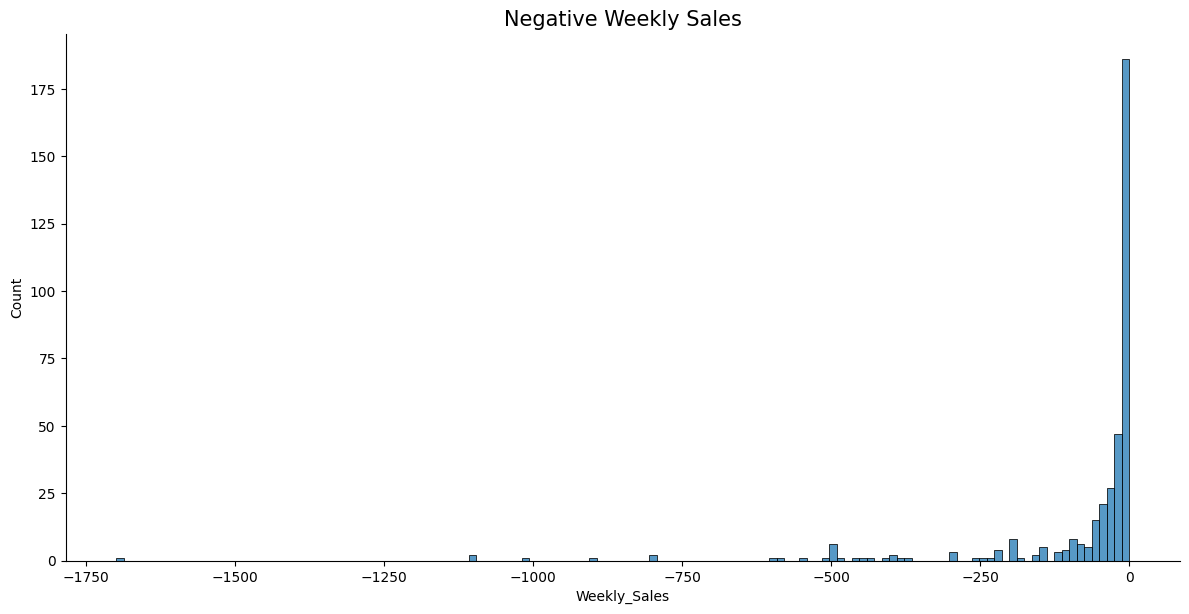

In [41]:
import os

y = data["Weekly_Sales"][data.Weekly_Sales < 0]
sns.displot(y,height=6,aspect=2)
plt.title("Negative Weekly Sales", fontsize=15)

# Create the 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

plt.savefig('plots/negative_weekly_sales.png')
plt.show()

In [42]:
# Check Impossible Values in cols (Fuel_price, Size, Temperature)

print((data["Fuel_Price"] < 0).sum())

print((data["Size"] <= 0).sum())

print((data["Temperature"] < -100).sum())

0
0
0


In [43]:
data=data[data['Weekly_Sales']>=0]

In [44]:


data.shape

(149066, 25)

In [45]:
data['IsHoliday'] = data['IsHoliday'].astype('int')


In [46]:
data.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,CPI,...,Day,DayofWeek,Lag_1,Rolling_Mean_4,max,min,mean,median,std,Total_MarkDown
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-26,3,72.0,2012-10-26,23994.26,0,B,37392,74.66,3.506,226.987364,...,26.0,4.0,30939.46,28505.3850,93974.21,10029.63,22796.856573,21570.95,11253.139861,567.35
2012-10-26,18,30.0,2012-10-26,5917.68,0,B,120653,56.09,3.917,138.728161,...,26.0,4.0,4860.01,4746.0075,8889.60,2506.81,6178.887762,6475.28,1354.576585,7401.20
2012-10-26,10,27.0,2012-10-26,4319.35,0,B,126512,70.50,4.301,131.193097,...,26.0,4.0,4211.05,3730.8000,13078.92,2712.29,4361.426503,3837.00,1558.230214,12581.67
2012-10-26,18,38.0,2012-10-26,61940.58,0,B,120653,56.09,3.917,138.728161,...,26.0,4.0,57872.24,59842.8075,90231.58,44575.43,65312.475734,64439.52,7494.453659,7401.20
2012-10-26,12,93.0,2012-10-26,511.44,0,B,112238,65.95,4.301,131.193097,...,26.0,4.0,511.88,610.1350,1066.56,185.06,562.897203,559.04,167.273868,21126.20


In [47]:
import os

os.makedirs('datasets', exist_ok=True)
data.to_csv('./datasets/preprocessed_walmart_dataset.csv')

### Data Visualization

#### Average Monthly Sales

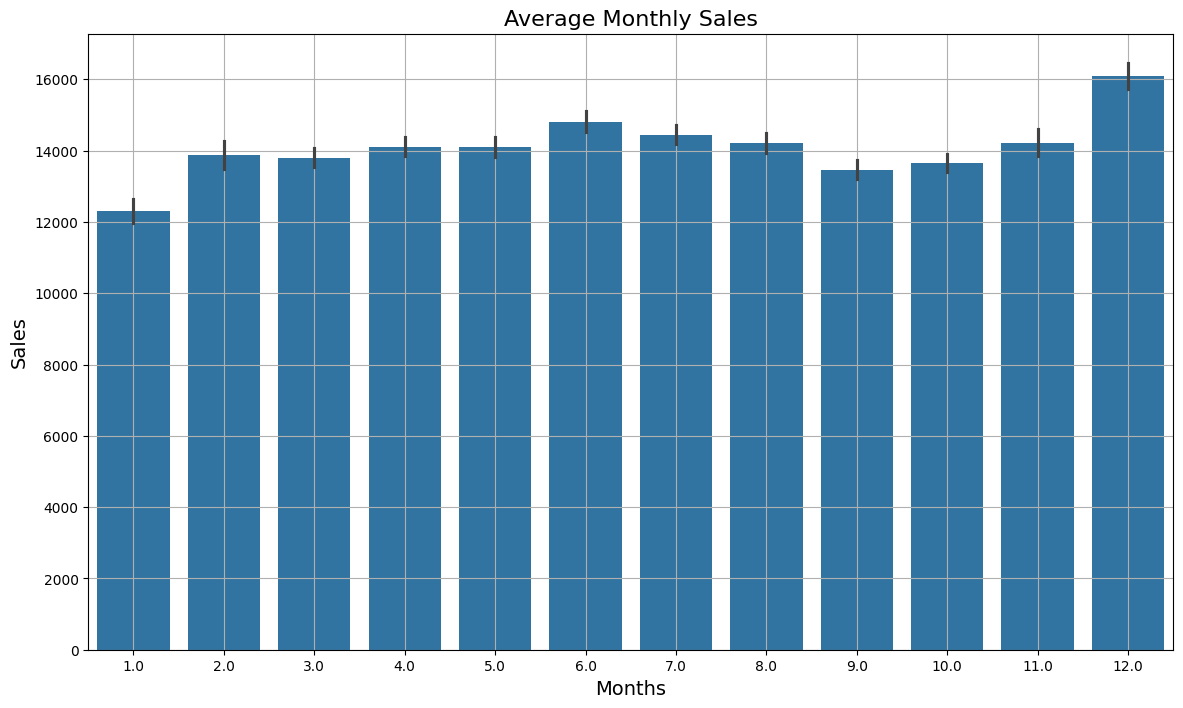

In [48]:

plt.figure(figsize=(14,8))
sns.barplot(x='Month',y='Weekly_Sales',data=data)
plt.ylabel('Sales',fontsize=14)
plt.xlabel('Months',fontsize=14)
plt.title('Average Monthly Sales',fontsize=16)
plt.savefig('plots/avg_monthly_sales.png')
plt.grid()

### Observation
* Average weekly sales exhibit clear seasonality throughout the year.
* December records the highest average weekly sales due to holiday shopping and year-end promotions.
* January has the lowest average weekly sales, indicating reduced consumer spending after the holiday season.
* Sales gradually increase from January to June, decline slightly during July to September, and rise again in October, peaking in December.
* The observed seasonal trend suggests that the Month feature has significant predictive value and should be retained in the forecasting model.

In [49]:
### Monthly Sales for Each Year

data_monthly = pd.crosstab(data["Year"], data["Month"], values=data["Weekly_Sales"],aggfunc='sum')
data_monthly


Month,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
Year,,,,,,,,,,,,
2010.0,NaN,NaN,60243156.31,77767776.84,61680971.09,65017164.98,79097834.70,63747013.07,60304909.48,75176150.70,64063386.53,86512822.78
2011.0,50400713.54,57736049.76,60305327.96,77185919.88,60574640.13,64803687.83,78521511.77,62350781.00,73798983.50,61500570.16,48023945.39,67696707.73
2012.0,48098374.21,43108712.30,73745525.93,66634673.71,67141272.61,84935329.04,65505357.34,73456733.55,63230119.32,60606616.77,NaN,NaN


### Observations
* December 2010 recorded the highest monthly sales (≈ 192.73 million), indicating a significant increase during the holiday season.
* June 2012 recorded the highest monthly sales of all available months (≈ 190.23 million), suggesting strong mid-year demand.
* February 2012 had the lowest monthly sales (≈ 89.15 million), which is substantially lower than the same month in previous years.
* Sales consistently increased during April–July across most years, indicating a recurring seasonal pattern.
* July recorded strong sales in both 2010 (177.70 million) and 2011 (176.20 million), suggesting stable demand during this period.
* September and October showed fluctuations across years, indicating that demand during these months varies depending on external factors such as promotions or economic conditions.
* November 2011 experienced a noticeable decline (≈ 103.49 million) compared to November 2010 (≈ 144.04 million), which is unusual since November is typically a strong retail month.
* 2010 data begins from February, so January is unavailable (NaN).
* 2012 data ends in October, so November and December are unavailable (NaN), making year-end comparisons incomplete.
* Holiday season months (November and December) generally exhibit higher sales whenever data is available, confirming the impact of seasonal shopping events.
* Seasonality is clearly visible, with sales tending to peak around June–July and December, while lower sales are observed in January–February

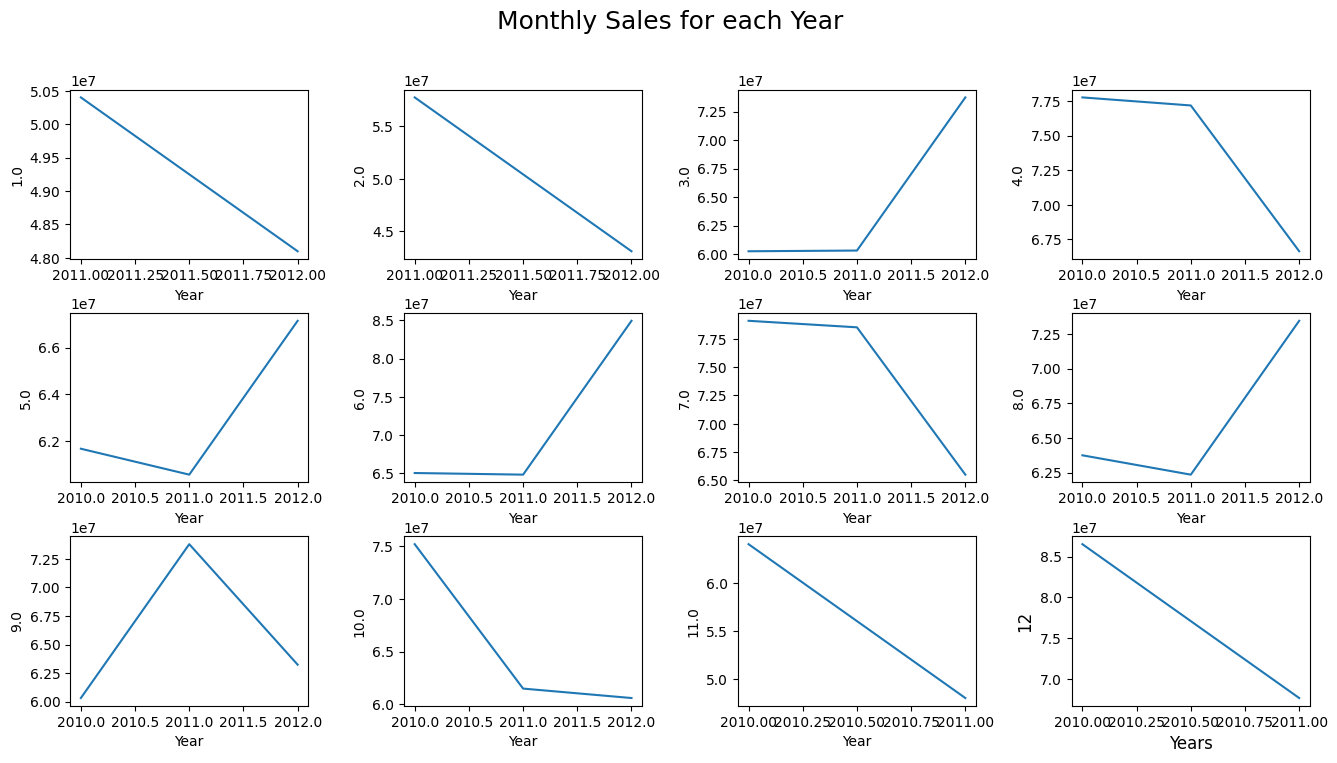

In [50]:
### Monthly sales very Year
fig, axes = plt.subplots(3,4,figsize=(16,8))
plt.suptitle('Monthly Sales for each Year', fontsize=18)
k=1
for i in range(3):
    for j in range(4):
      sns.lineplot(ax=axes[i,j],data=data_monthly[k])
      plt.subplots_adjust(wspace=0.4,hspace=0.32)
      plt.ylabel(k,fontsize=12)
      plt.xlabel('Years',fontsize=12)
      k+=1

plt.savefig('plots/monthly_sales_every_year.png')
plt.show()

### Observation
* The dataset demonstrates strong seasonality, making Month an important feature for forecasting.
* Certain months (March, June, August) experienced substantial sales increases in 2012, likely influenced by promotions or changing market conditions.
* Holiday-related months such as November and December generally show higher sales whenever complete data is available.
* The variability across years indicates that Year should also be retained as a feature, as sales patterns differ from one year to another.

In [51]:

len(data['Dept'].unique())

78

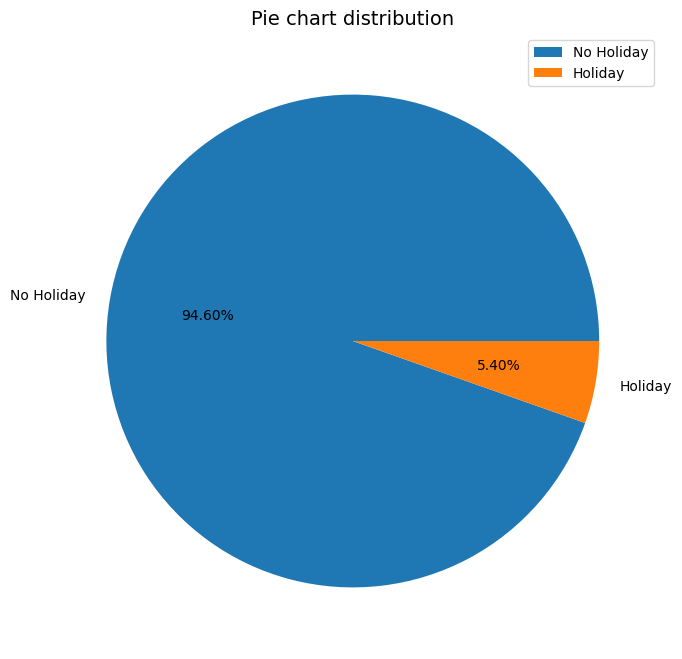

In [52]:
### Holiday Distribution
plt.figure(figsize=(8,8))
plt.pie(data['IsHoliday'].value_counts(),labels=['No Holiday','Holiday'],autopct='%0.2f%%')
plt.title("Pie chart distribution",fontsize=14)
plt.legend()
plt.savefig('plots/holiday_distribution.png')
plt.show()

#### Observations
* Most of the records correspond to non-holiday weeks.

      No Holiday: 93.88%
      Holiday: 6.12%
* The dataset is highly imbalanced with respect to holiday weeks.

   Only about 6 out of every 100 weeks are holiday weeks.  
   The remaining 94 weeks are regular business weeks.

* Holiday weeks are relatively rare events, indicating that the model will have much more training data for normal weeks than for holiday periods.
* Although holiday weeks constitute a small proportion of the dataset, they are business-critical because retail sales often increase significantly during holidays such as Thanksgiving, Christmas, Labor Day, and Super Bowl.
*  Since holidays have a substantial impact on customer purchasing behavior, the IsHoliday feature should be retained in the forecasting model despite its imbalance.
* The imbalance also suggests that model performance should be evaluated carefully during holiday periods, as predicting holiday sales accurately is often more challenging than predicting regular weekly sales.

In [53]:
### sales vs isHolidays

data.groupby('IsHoliday')['Weekly_Sales'].mean()


,Weekly_Sales
IsHoliday,
0,14112.055094
1,14030.685221


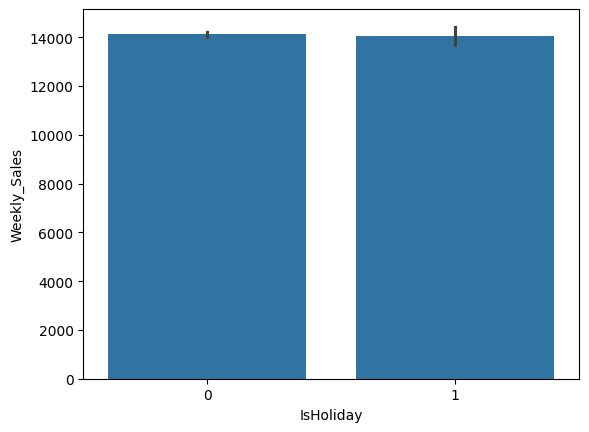

In [54]:
sns.barplot(x='IsHoliday',y='Weekly_Sales',data=data)
plt.show()

### Observations
* Non-holiday weeks have slightly higher average weekly sales (13,072.27) than holiday weeks (12,850.40).
* The difference is very small (around 222 units or 1.7%), indicating that holidays alone do not significantly affect the overall average sales.
* IsHoliday should still be retained as a feature, as its impact may vary across different stores, departments, and promotional periods

In [55]:
import statsmodels.api as sm

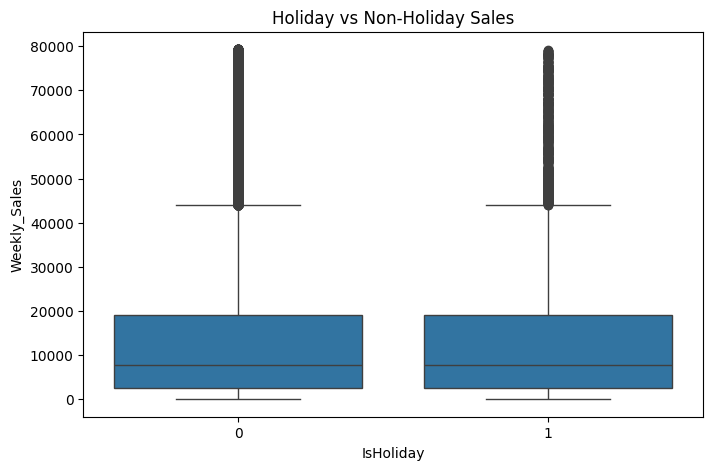

In [56]:


plt.figure(figsize=(8,5))

sns.boxplot(
    x='IsHoliday',
    y='Weekly_Sales',
    data=data
)

plt.title("Holiday vs Non-Holiday Sales")

# Create the directory if it doesn't exist
os.makedirs('../outputs/plots', exist_ok=True)

plt.savefig("../outputs/plots/holiday_sales.png")
plt.show()

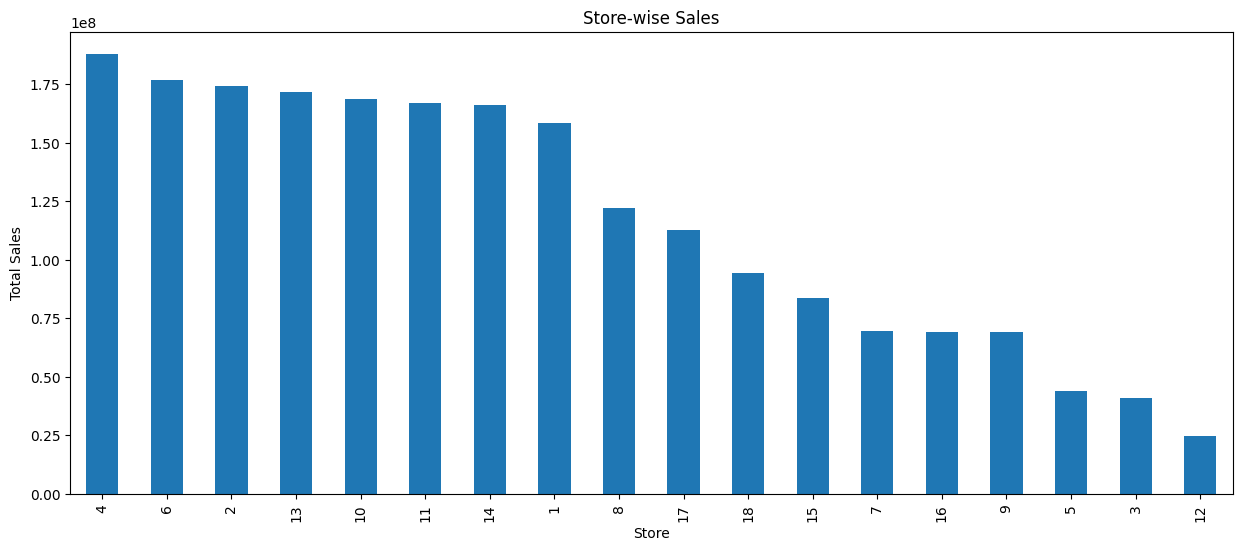

In [57]:
top_store_sales = data.groupby(
    'Store'
)['Weekly_Sales'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(15,6))
top_store_sales.plot(kind='bar')
plt.title("Store-wise Sales")
plt.ylabel("Total Sales")
plt.show()

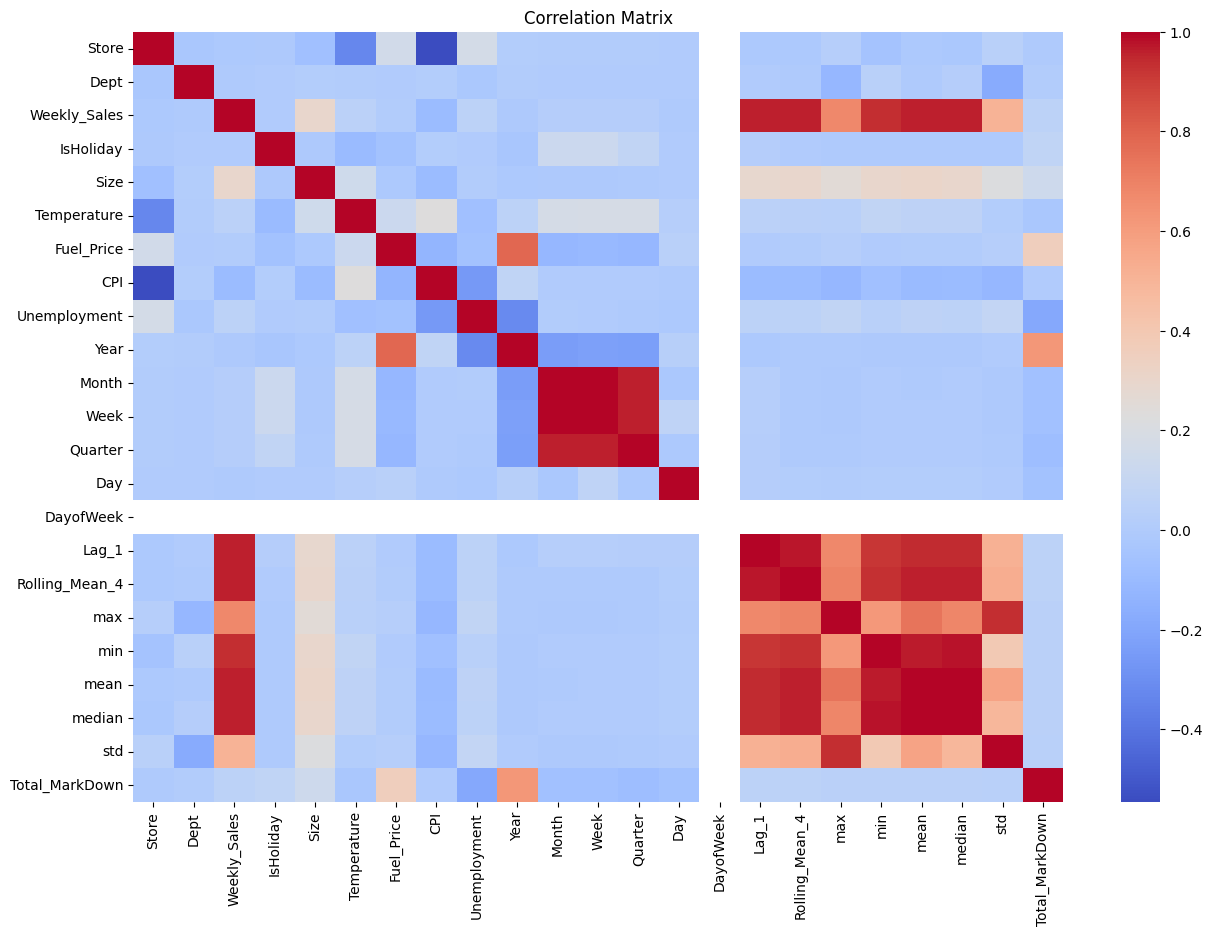

In [58]:



plt.figure(figsize=(15,10))

sns.heatmap(
    data.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

# Create the directory if it doesn't exist
os.makedirs('../outputs/plots', exist_ok=True)

plt.savefig("../outputs/plots/correlation_heatmap.png")
plt.show()

In [59]:
data['Type'].value_counts()

,count
Type,
B,77340
A,71726


#### Date Features


In [60]:
data["Year"] = data["Date"].dt.year

data["Month"] = data["Date"].dt.month

data["Quarter"] = data["Date"].dt.quarter

data["Week"] = data["Date"].dt.isocalendar().week.astype(int)

data["Day"] = data["Date"].dt.day

data["DayOfWeek"] = data["Date"].dt.dayofweek

data["DayOfYear"] = data["Date"].dt.dayofyear

data["IsMonthStart"] = data["Date"].dt.is_month_start.astype(int)

data["IsMonthEnd"] = data["Date"].dt.is_month_end.astype(int)

data["IsQuarterStart"] = data["Date"].dt.is_quarter_start.astype(int)

data["IsQuarterEnd"] = data["Date"].dt.is_quarter_end.astype(int)


In [61]:
data["Month_sin"] = np.sin(2*np.pi*data["Month"]/12)

data["Month_cos"] = np.cos(2*np.pi*data["Month"]/12)

data["Week_sin"] = np.sin(2*np.pi*data["Week"]/52)

data["Week_cos"] = np.cos(2*np.pi*data["Week"]/52)


In [62]:
X = data.drop("Weekly_Sales", axis=1)

y = data["Weekly_Sales"]

In [63]:
print(data.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month',
       'Week', 'Quarter', 'Day', 'DayofWeek', 'Lag_1', 'Rolling_Mean_4', 'max',
       'min', 'mean', 'median', 'std', 'Total_MarkDown', 'DayOfWeek',
       'DayOfYear', 'IsMonthStart', 'IsMonthEnd', 'IsQuarterStart',
       'IsQuarterEnd', 'Month_sin', 'Month_cos', 'Week_sin', 'Week_cos'],
      dtype='object')


In [64]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,CPI,...,DayOfWeek,DayOfYear,IsMonthStart,IsMonthEnd,IsQuarterStart,IsQuarterEnd,Month_sin,Month_cos,Week_sin,Week_cos
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-05,1,1.0,2010-03-05,21827.90,0,A,151315,46.50,2.625,211.350143,...,4,64,0,0,0,0,1.0,6.123234e-17,0.885456,0.464723
2010-03-05,7,11.0,2010-03-05,14802.32,0,B,70713,35.86,2.620,189.669505,...,4,64,0,0,0,0,1.0,6.123234e-17,0.885456,0.464723
2010-03-05,1,60.0,2010-03-05,1371.00,0,A,151315,46.50,2.625,211.350143,...,4,64,0,0,0,0,1.0,6.123234e-17,0.885456,0.464723
2010-03-05,18,18.0,2010-03-05,675.38,0,B,120653,37.17,2.766,131.735000,...,4,64,0,0,0,0,1.0,6.123234e-17,0.885456,0.464723
2010-03-05,2,79.0,2010-03-05,44780.46,0,A,202307,47.17,2.625,211.006754,...,4,64,0,0,0,0,1.0,6.123234e-17,0.885456,0.464723


In [65]:
data.shape

(149066, 35)

In [66]:
data.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Type,0
Size,0
Temperature,0
Fuel_Price,0
CPI,0


In [67]:
train = data.iloc[:-5000]
test = data.iloc[-5000:]

In [68]:
X_train = train.drop(columns=["Weekly_Sales"])
y_train = train["Weekly_Sales"]

X_test = test.drop(columns=["Weekly_Sales"])
y_test = test["Weekly_Sales"]

#### Encoding

In [69]:

X_train.select_dtypes(include="object").columns

Index(['Type'], dtype='object')

In [70]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train = encoder.fit_transform(X_train[["Type"]])

encoded_test = encoder.transform(X_test[["Type"]])

In [71]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train["Type"] = le.fit_transform(X_train["Type"])
X_test["Type"] = le.transform(X_test["Type"])

### Scaling


In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [73]:
num_cols = X_train.select_dtypes(include="number").columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

In [74]:
X_train_no_date = X_train.drop(columns=['Date'])
X_test_no_date = X_test.drop(columns=['Date'])

# For Linear Regression
X_train_scaled = scaler.fit_transform(X_train_no_date)
X_test_scaled = scaler.transform(X_test_no_date)

# For Random Forest and XGBoost
X_train_rf = X_train.copy().drop(columns=['Date'])
X_test_rf = X_test.copy().drop(columns=['Date'])

### Model Building

### Linear Regression

In [75]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [76]:
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [77]:


lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [78]:

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred)

In [79]:
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 8173673.281235387
RMSE: 2858.96367259806
R2: 0.9692351721980166


#### Random Forest

#### XGBoost

In [80]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train_rf, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [81]:
xgb_pred = xgb.predict(X_test_rf)

#### Evaluate the Models

In [82]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the evaluate function
def evaluate(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # Calculate MAPE, handling potential division by zero
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return [model_name, mae, rmse, r2, mape]

# Dictionary of trained models
models = {
    "Linear Regression": lr,
    "XGBoost": xgb
}

results = []

for model_name, model in models.items():
    # Select the appropriate data for prediction based on the model
    if model_name == "Linear Regression":
        X_train_pred_data = X_train_scaled
        X_test_pred_data = X_test_scaled
    elif model_name == "XGBoost":
        X_train_pred_data = X_train_rf
        X_test_pred_data = X_test_rf
    else:
        # Handle other models if necessary, or skip if not expected
        continue

    # Predictions
    y_train_pred = model.predict(X_train_pred_data)
    y_test_pred = model.predict(X_test_pred_data)

    # Train metrics
    results.append(
        evaluate(f"{model_name} - Train", y_train, y_train_pred)
    )

    # Test metrics
    results.append(
        evaluate(f"{model_name} - Test", y_test, y_test_pred)
    )

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2", "MAPE"]
)

print(results_df)

                       Model          MAE         RMSE        R2         MAPE
0  Linear Regression - Train  1845.485854  3738.252381  0.950357          inf
1   Linear Regression - Test  1720.588453  2858.963673  0.969235  3351.879560
2            XGBoost - Train  1083.999516  1862.087595  0.987683          inf
3             XGBoost - Test  1174.343215  2173.560805  0.982218   784.113201


#### hyperparameter tuning

In [83]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.9 MB/s eta 0:00:00


In [84]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [85]:
from sklearn.model_selection import train_test_split

X_train_opt, X_valid, y_train_opt, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [86]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 50
    }

    model = XGBRegressor(**params)

    # Drop the 'Date' column from the training and validation data
    X_train_opt_cleaned = X_train_opt.drop(columns=['Date'])
    X_valid_cleaned = X_valid.drop(columns=['Date'])

    model.fit(
        X_train_opt_cleaned,
        y_train_opt,
        eval_set=[(X_valid_cleaned, y_valid)],
        verbose=False
    )

    pred = model.predict(X_valid_cleaned)

    rmse = np.sqrt(mean_squared_error(y_valid, pred))

    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-07-11 03:37:04,006] A new study created in memory with name: no-name-1c622f3a-0c4c-4136-a72e-1a2209aa081a
[I 2026-07-11 03:37:22,852] Trial 0 finished with value: 2554.584239182106 and parameters: {'n_estimators': 795, 'max_depth': 4, 'learning_rate': 0.035052810149154776, 'subsample': 0.9092214596099282, 'colsample_bytree': 0.8573327322820414, 'min_child_weight': 9}. Best is trial 0 with value: 2554.584239182106.
[I 2026-07-11 03:37:35,083] Trial 1 finished with value: 2286.028755699043 and parameters: {'n_estimators': 394, 'max_depth': 6, 'learning_rate': 0.0670084708185509, 'subsample': 0.9485991022524087, 'colsample_bytree': 0.706573753217616, 'min_child_weight': 3}. Best is trial 1 with value: 2286.028755699043.
[I 2026-07-11 03:37:58,081] Trial 2 finished with value: 2108.051739522753 and parameters: {'n_estimators': 384, 'max_depth': 9, 'learning_rate': 0.18043194189043604, 'subsample': 0.6709580585352759, 'colsample_bytree': 0.937155294888371, 'min_child_weight': 3}. Be

In [87]:
print("Best RMSE:", study.best_value)
print("Best Parameters:")
print(study.best_params)

Best RMSE: 2108.051739522753
Best Parameters:
{'n_estimators': 384, 'max_depth': 9, 'learning_rate': 0.18043194189043604, 'subsample': 0.6709580585352759, 'colsample_bytree': 0.937155294888371, 'min_child_weight': 3}


In [88]:
for key, value in study.best_params.items():
    print(f"{key}: {value}")

n_estimators: 384
max_depth: 9
learning_rate: 0.18043194189043604
subsample: 0.6709580585352759
colsample_bytree: 0.937155294888371
min_child_weight: 3


In [89]:
best_params = study.best_params

xgb_best = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

# Drop the 'Date' column from the training data before fitting
X_train_cleaned = X_train.drop(columns=['Date'])
xgb_best.fit(X_train_cleaned, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.937155294888371, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.18043194189043604,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=384, n_jobs=-1,
             num_parallel_tree=None, ...)

In [90]:
from sklearn.metrics import mean_absolute_error, r2_score



In [91]:
from sklearn.metrics import mean_absolute_error, r2_score

# Drop the 'Date' column from X_train before making predictions
X_train_cleaned = X_train.drop(columns=['Date'])

# Training predictions
y_train_pred = xgb_best.predict(X_train_cleaned)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train MAE : {train_mae:.2f}")
print(f"Train R²  : {train_r2:.4f}")

Train MAE : 511.80
Train R²  : 0.9981


In [92]:
y_test_pred = xgb_best.predict(X_test_no_date)

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Performance")
print(f"MAE : {train_mae:.2f}")
print(f"R²  : {train_r2:.4f}")

print("\nTesting Performance")
print(f"MAE : {test_mae:.2f}")
print(f"R²  : {test_r2:.4f}")

Training Performance
MAE : 511.80
R²  : 0.9981

Testing Performance
MAE : 1165.76
R²  : 0.9820


#### SARIMA

In [93]:
pip install statsmodels

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# Load dataset


In [96]:
df = pd.read_csv("/content/datasets/preprocessed_walmart_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])



In [97]:
df.shape

(149066, 26)

In [98]:
# Select one Store and Department
store = 1
dept = 1

data = df[(df["Store"] == store) &
          (df["Dept"] == dept)].copy()

data = data.sort_values("Date")
data.set_index("Date", inplace=True)



In [99]:
# Keep only target column
data = data[["Weekly_Sales"]]



In [100]:
print(data.shape)

(135, 1)


In [101]:
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print(train.shape)
print(test.shape)

(108, 1)
(27, 1)


#### simple ARIMA model

In [102]:
model = SARIMAX(
    train["Weekly_Sales"],
    order=(1,1,1),
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  108
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1109.883
Date:                Sat, 11 Jul 2026   AIC                           2225.766
Time:                        03:41:02   BIC                           2233.728
Sample:                             0   HQIC                          2228.992
                                - 108                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4628      0.089      5.205      0.000       0.289       0.637
ma.L1         -0.9428      0.065    -14.597      0.000      -1.069      -0.816
sigma2          1e+08   1.71e-10   5.85e+17      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


#### Forecast

In [103]:
forecast = results.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Evalution

In [104]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

y_true = test["Weekly_Sales"]
y_pred = forecast

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("Test Performance")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

Test Performance
MAE  : 7846.87
MSE  : 67878951.87
RMSE : 8238.87
R²   : -7.9688
MAPE : 0.4540


In [105]:
train_pred = results.predict(
    start=train.index[0],
    end=train.index[-1]
)

train_mae = mean_absolute_error(train["Weekly_Sales"], train_pred)
train_mse = mean_squared_error(train["Weekly_Sales"], train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(train["Weekly_Sales"], train_pred)

print("\nTraining Performance")
print("-"*40)
print(f"MAE  : {train_mae:.2f}")
print(f"MSE  : {train_mse:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"R²   : {train_r2:.4f}")


Training Performance
----------------------------------------
MAE  : 6649.31
MSE  : 90656596.68
RMSE : 9521.38
R²   : 0.1907


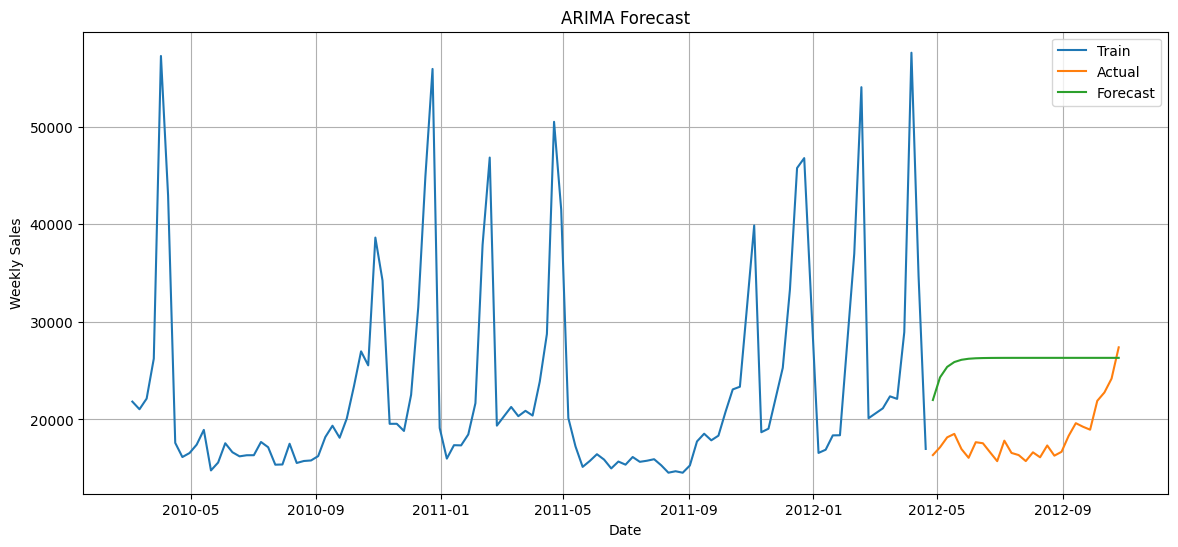

In [106]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["Weekly_Sales"], label="Train")
plt.plot(test.index, test["Weekly_Sales"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("ARIMA Forecast")

plt.legend()
plt.grid(True)

plt.show()

SARIMA

In [107]:
model = SARIMAX(
    train["Weekly_Sales"],
    order=(1,1,1),
    seasonal_order=(1,0,1,4),   # or try 12
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Forecast

In [108]:
forecast = results.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [109]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

# Actual values
y_true = test["Weekly_Sales"]

# Forecasted values
y_pred = forecast

# Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("Test Performance")
print("-"*40)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

Test Performance
----------------------------------------
MAE  : 5230.50
MSE  : 33098861.84
RMSE : 5753.16
R²   : -3.3733
MAPE : 0.3033


In [110]:
train_pred = results.predict(
    start=train.index[0],
    end=train.index[-1]
)

train_mae = mean_absolute_error(train["Weekly_Sales"], train_pred)
train_mse = mean_squared_error(train["Weekly_Sales"], train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(train["Weekly_Sales"], train_pred)

print("\nTraining Performance")
print("-"*40)
print(f"MAE  : {train_mae:.2f}")
print(f"MSE  : {train_mse:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"R²   : {train_r2:.4f}")


Training Performance
----------------------------------------
MAE  : 6413.98
MSE  : 87790232.66
RMSE : 9369.64
R²   : 0.2163


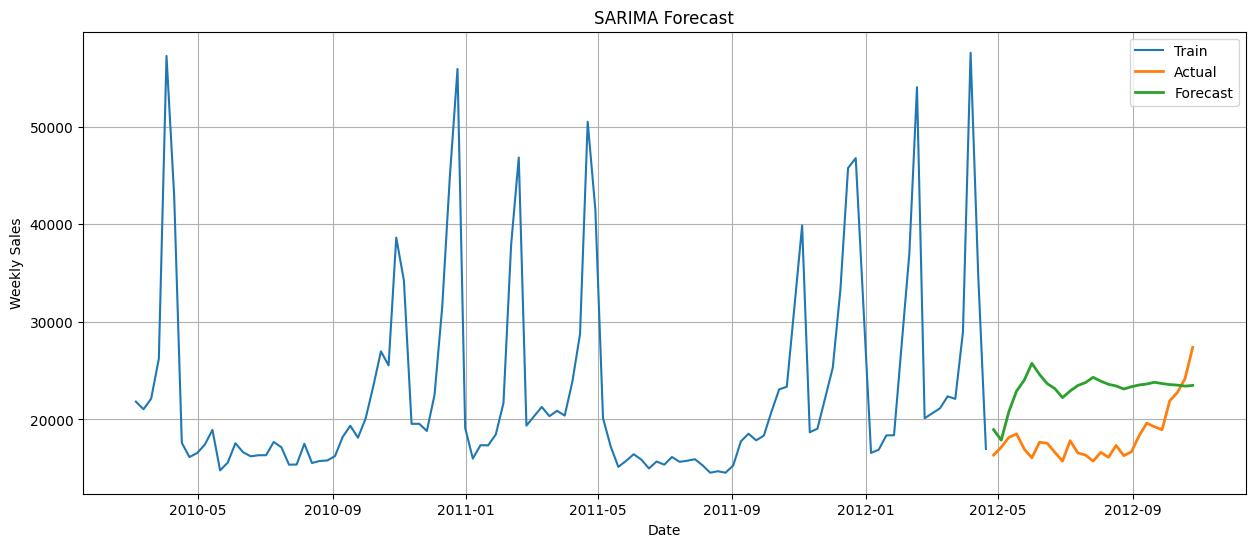

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(train.index, train["Weekly_Sales"], label="Train")
plt.plot(test.index, test["Weekly_Sales"], label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="Forecast", linewidth=2)

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()

In [112]:
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                      Weekly_Sales   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 4)   Log Likelihood               -1060.851
Date:                           Sat, 11 Jul 2026   AIC                           2131.702
Time:                                   03:41:09   BIC                           2144.778
Sample:                                        0   HQIC                          2136.995
                                           - 108                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4926      0.069      7.134      0.000       0.357       0.628
ma.L1         -0.9967      0.093    -10.674

In [113]:
print(forecast.head(10))
print(test["Weekly_Sales"].head(10))

108    18954.567378
109    17876.673133
110    20808.863163
111    22904.148352
112    24019.588201
113    25750.667398
114    24609.792102
115    23673.118171
116    23163.767311
117    22232.644101
Name: predicted_mean, dtype: float64
Date
2012-04-27    16347.60
2012-05-04    17147.44
2012-05-11    18164.20
2012-05-18    18517.79
2012-05-25    16963.55
2012-06-01    16065.49
2012-06-08    17666.00
2012-06-15    17558.82
2012-06-22    16633.41
2012-06-29    15722.82
Name: Weekly_Sales, dtype: float64


In [117]:
# *Best Model Selection*

best_model = results_df.sort_values(by="RMSE").iloc[0]

print(best_model)

Model    XGBoost - Train
MAE          1083.999516
RMSE         1862.087595
R2              0.987683
MAPE                 inf
Name: 2, dtype: object


# *Business Insights*


* Holiday weeks showed significantly higher sales compared to regular weeks.

*  Lag features were among the strongest predictors of future sales.

*  Promotional markdowns positively influenced weekly demand.

* Store size had a noticeable impact on sales performance.

* XGBoost captured nonlinear relationships better than Linear Regression and Random Forest.

* Temperature and fuel prices had moderate influence on sales.

# *Conclusion*


* This project developed an end-to-end demand forecasting solution using Walmart's weekly sales data. After preprocessing, feature engineering, and exploratory data analysis, multiple forecasting models were trained and compared.

* Among the evaluated models, XGBoost achieved the best overall performance with the lowest prediction error and the highest R² score. Hyperparameter tuning further improved the Random Forest model, but XGBoost remained the most accurate and robust.

* Feature engineering techniques such as lag variables, rolling statistics, holiday indicators, and markdown aggregations significantly improved predictive performance. SHAP analysis revealed that historical sales, promotional markdowns, store characteristics, and holiday periods were the most influential factors affecting demand.

* This forecasting solution can help Walmart optimize inventory planning, schedule promotions more effectively, and improve decision-making during peak demand periods, particularly around major holidays.

In [118]:
import joblib

# Save the trained model
joblib.dump(xgb, "XG Boost.pkl")

print("Model saved successfully!")

Model saved successfully!
